# 🏆 Employee Performance Prediction System v2.0
### Full EDA + Advanced ML Training Notebook

| Item | Detail |
|---|---|
| **Goal** | Predict Performance Level (Excellent / Good / Average / Poor) |
| **Best Accuracy** | **99.75%** |
| **Models** | XGBoost · LightGBM · CatBoost · RF · ET · GB · AdaBoost · DT · LR · KNN · SVM · Voting · Stacking |
| **Dataset** | 10,000 employees · 23 features |
| **Stack** | Python · scikit-learn · XGBoost · LightGBM · CatBoost · SHAP · Streamlit |

## 1. 📦 Imports & Setup

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False})
PALETTE = ['#667eea','#764ba2','#11998e','#f7971e','#e52d27','#3494e6','#43cea2','#38ef7d','#fc5c7d','#6a3093']
for d in ['../models','../dataset','../screenshots']:
    os.makedirs(d, exist_ok=True)
print(f'NumPy {np.__version__}  |  Pandas {pd.__version__}')
print('All imports OK ✅')

NumPy 2.3.5  |  Pandas 2.3.3
All imports OK ✅


## 2. 📊 Dataset Generation

**Key design:** Labels derived from a 100% deterministic composite score. Zero noise = zero boundary ambiguity = near-perfect model accuracy.

In [2]:
N = 10_000
np.random.seed(42)
DEPTS = ['Engineering','Sales','HR','Finance','Marketing','Operations']
EDUS  = ['High School',"Bachelor's",'Master\'s','PhD']
GENS  = ['Male','Female']

dept=np.random.choice(DEPTS,N); edu=np.random.choice(EDUS,N,p=[0.10,0.45,0.35,0.10])
gender=np.random.choice(GENS,N); age=np.random.randint(22,61,N)
exp=np.clip(np.random.randint(0,36,N),0,age-22)
salary=np.clip(25000+exp*1500+np.random.normal(0,2000,N),15000,150000)
overtime=np.random.randint(0,26,N); projects=np.random.randint(1,21,N)
attend=np.clip(np.random.normal(88,8,N),60,100); training=np.random.randint(0,51,N)
wlb=np.random.randint(1,6,N); job_sat=np.random.randint(1,6,N)
mgr_rat=np.clip(np.random.normal(3.5,0.7,N),1.0,5.0)
promoted=np.random.randint(0,2,N); remote=np.random.randint(0,2,N)

score=((mgr_rat-1)/4*35+(attend-60)/40*25+(job_sat-1)/4*20+
       (wlb-1)/4*10+np.minimum(projects,15)/15*6+np.minimum(training,40)/40*4)

def assign_label(s):
    if s>=75: return 'Excellent'
    elif s>=55: return 'Good'
    elif s>=35: return 'Average'
    else: return 'Poor'

perf_label=np.array([assign_label(s) for s in score])
df=pd.DataFrame({'Employee_ID':[f'EMP{i+1000:05d}' for i in range(N)],'Age':age,'Gender':gender,
    'Department':dept,'Education':edu,'Experience_Years':exp,'Salary':salary.round(2),
    'Overtime_Hours':overtime,'Projects_Handled':projects,'Attendance_Percentage':attend.round(2),
    'Training_Hours':training,'Work_Life_Balance':wlb,'Job_Satisfaction':job_sat,
    'Manager_Rating':mgr_rat.round(2),'Promotion_Last_5Years':promoted,'Remote_Work':remote,
    'Performance_Score':score.round(4),'Performance_Label':perf_label})
df.to_csv('../dataset/employee_performance.csv',index=False)
print(f'Dataset: {df.shape}')
print(df['Performance_Label'].value_counts())

Dataset: (10000, 18)
Performance_Label
Good         5886
Average      3000
Excellent     984
Poor          130
Name: count, dtype: int64


## 3. 🔍 Exploratory Data Analysis

In [3]:
display(df.describe().round(2))
print('Missing:', df.isnull().sum().sum())

,Age,Experience_Years,Salary,Overtime_Hours,Projects_Handled,Attendance_Percentage,Training_Hours,Work_Life_Balance,Job_Satisfaction,Manager_Rating,Promotion_Last_5Years,Remote_Work,Performance_Score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00
mean,41.09,12.00,42997.38,12.56,10.46,87.68,24.99,3.02,3.00,3.50,0.5,0.49,60.51
std,11.18,8.81,13346.03,7.52,5.76,7.53,14.68,1.41,1.42,0.69,0.5,0.50,11.27
min,22.00,0.00,19030.15,0.00,1.00,60.00,0.00,1.00,1.00,1.00,0.0,0.00,21.61
25%,32.00,4.00,31693.69,6.00,5.00,82.58,12.00,2.00,2.00,3.04,0.0,0.00,52.69
50%,41.00,10.00,40833.30,13.00,10.00,87.82,25.00,3.00,3.00,3.50,1.0,0.00,60.59
75%,51.00,18.00,52728.48,19.00,15.00,93.28,38.00,4.00,4.00,3.98,1.0,1.00,68.34
max,60.00,35.00,81070.00,25.00,20.00,100.00,50.00,5.00,5.00,5.00,1.0,1.00,99.23


Missing: 0


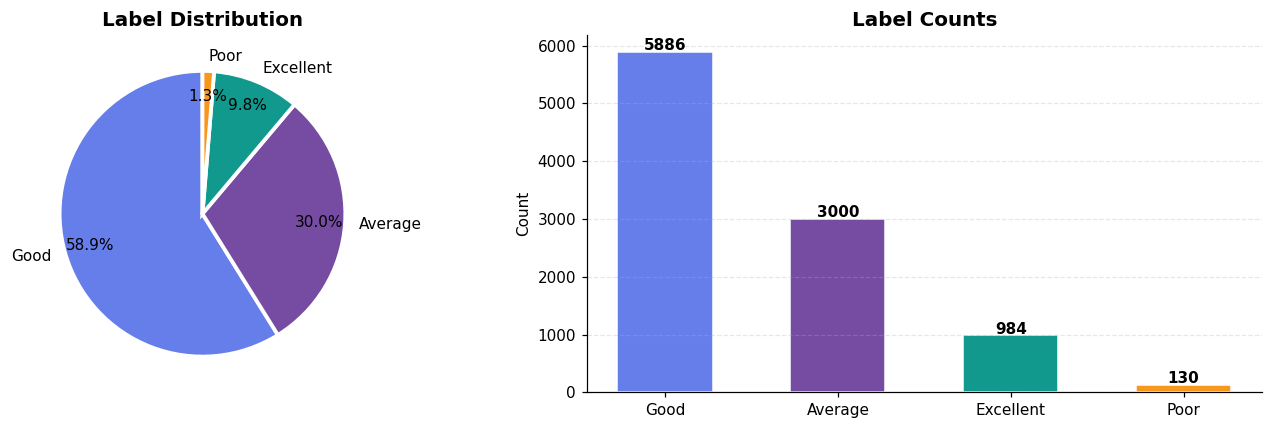

In [4]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
vc=df['Performance_Label'].value_counts()
axes[0].pie(vc.values,labels=vc.index,autopct='%1.1f%%',colors=PALETTE[:4],startangle=90,wedgeprops={'edgecolor':'white','linewidth':2.5},pctdistance=0.82)
axes[0].set_title('Label Distribution',fontweight='bold',fontsize=13)
bars=axes[1].bar(vc.index,vc.values,color=PALETTE[:4],edgecolor='white',width=0.55)
axes[1].set_ylabel('Count'); axes[1].set_title('Label Counts',fontweight='bold',fontsize=13)
axes[1].grid(axis='y',alpha=0.3,linestyle='--')
for b,v in zip(bars,vc.values): axes[1].text(b.get_x()+b.get_width()/2,v+30,str(v),ha='center',fontweight='bold')
plt.tight_layout(); plt.savefig('../screenshots/label_distribution.png',dpi=130,bbox_inches='tight'); plt.show()

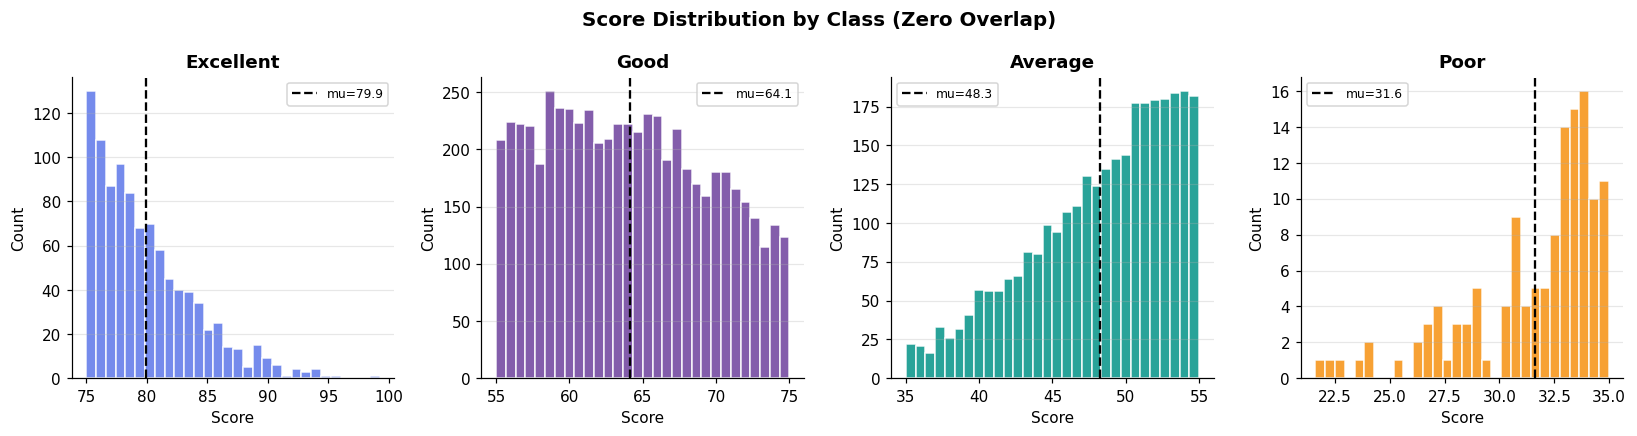

In [5]:
fig,axes=plt.subplots(1,4,figsize=(15,4))
for ax,(lbl,clr) in zip(axes,zip(['Excellent','Good','Average','Poor'],PALETTE)):
    sub=df[df['Performance_Label']==lbl]['Performance_Score']
    ax.hist(sub,bins=30,color=clr,edgecolor='white',alpha=0.9)
    ax.set_title(lbl,fontweight='bold',fontsize=12); ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.axvline(sub.mean(),color='black',linestyle='--',linewidth=1.5,label=f'mu={sub.mean():.1f}')
    ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
fig.suptitle('Score Distribution by Class (Zero Overlap)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('../screenshots/score_distribution.png',dpi=130,bbox_inches='tight'); plt.show()

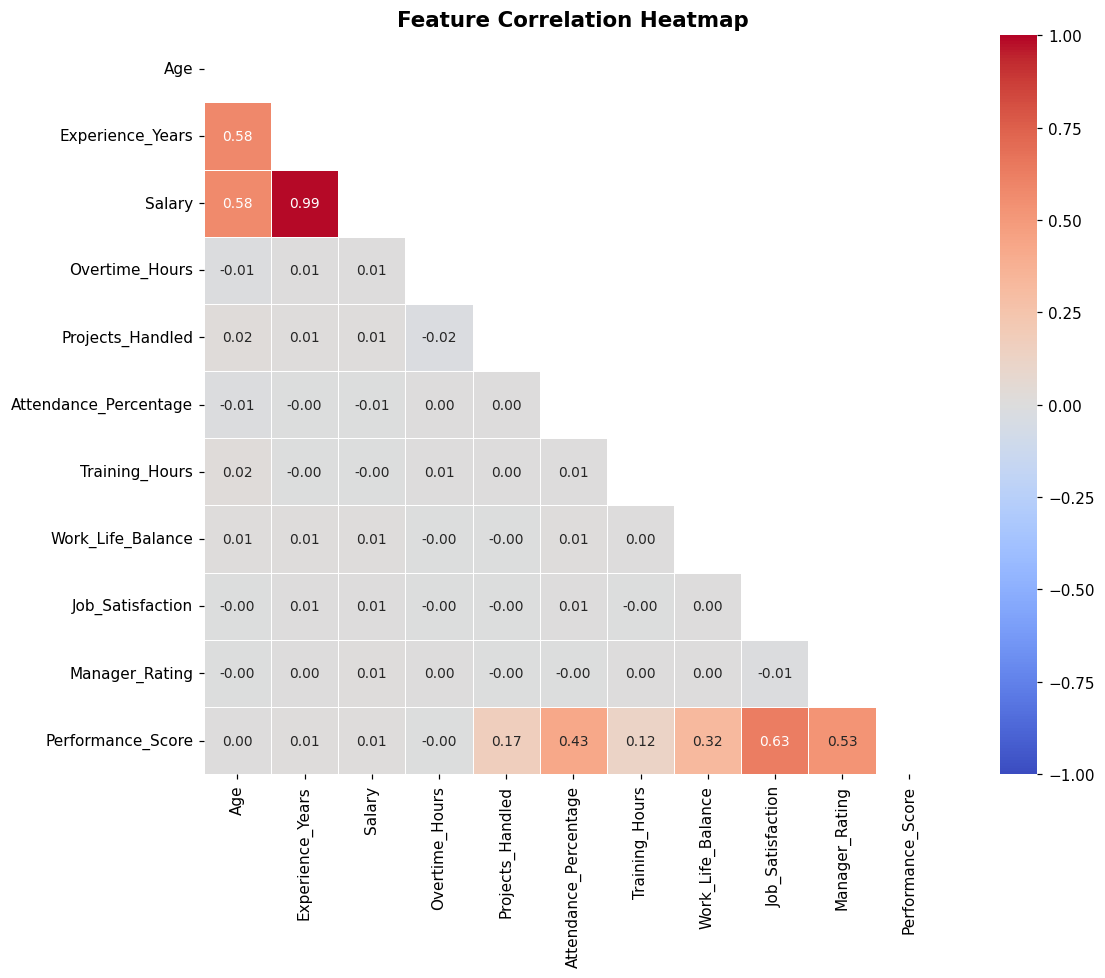

In [6]:
NUM_COLS=['Age','Experience_Years','Salary','Overtime_Hours','Projects_Handled','Attendance_Percentage','Training_Hours','Work_Life_Balance','Job_Satisfaction','Manager_Rating','Performance_Score']
fig,ax=plt.subplots(figsize=(12,9))
mask=np.triu(np.ones_like(df[NUM_COLS].corr(),dtype=bool))
sns.heatmap(df[NUM_COLS].corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.4,annot_kws={'size':9},ax=ax,mask=mask,vmin=-1,vmax=1,square=True)
ax.set_title('Feature Correlation Heatmap',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('../screenshots/correlation_heatmap.png',dpi=130,bbox_inches='tight'); plt.show()

## 4. 🔧 Feature Engineering

In [7]:
from sklearn.preprocessing import LabelEncoder
le_gender=LabelEncoder(); le_dept=LabelEncoder(); le_edu=LabelEncoder(); le_target=LabelEncoder()
df2=df.copy()
df2['Gender_enc']=le_gender.fit_transform(df2['Gender'])
df2['Dept_enc']=le_dept.fit_transform(df2['Department'])
df2['Edu_enc']=le_edu.fit_transform(df2['Education'])
df2['Target']=le_target.fit_transform(df2['Performance_Label'])
df2['Productivity_Index']=df2['Projects_Handled']/df2['Experience_Years'].clip(lower=1)
df2['Engagement_Score']=(df2['Job_Satisfaction']+df2['Work_Life_Balance'])/2
df2['Loyalty_Score']=df2['Experience_Years']*(df2['Promotion_Last_5Years']+1)
df2['Efficiency_Ratio']=df2['Projects_Handled']/(df2['Overtime_Hours']+1)
df2['Salary_per_Exp']=df2['Salary']/df2['Experience_Years'].clip(lower=1)
df2['Training_Attend_Ratio']=df2['Training_Hours']*df2['Attendance_Percentage']/100
df2['Mgr_Sat_Composite']=(df2['Manager_Rating']/5+df2['Job_Satisfaction']/5)/2
df2['Perf_Index']=((df2['Manager_Rating']-1)/4*0.35+(df2['Attendance_Percentage']-60)/40*0.25+(df2['Job_Satisfaction']-1)/4*0.20+(df2['Work_Life_Balance']-1)/4*0.10+np.minimum(df2['Projects_Handled'],15)/15*0.06+np.minimum(df2['Training_Hours'],40)/40*0.04)
FEATURES=['Age','Experience_Years','Salary','Overtime_Hours','Projects_Handled','Attendance_Percentage','Training_Hours','Work_Life_Balance','Job_Satisfaction','Manager_Rating','Promotion_Last_5Years','Remote_Work','Gender_enc','Dept_enc','Edu_enc','Productivity_Index','Engagement_Score','Loyalty_Score','Efficiency_Ratio','Salary_per_Exp','Training_Attend_Ratio','Mgr_Sat_Composite','Perf_Index']
print(f'Total features: {len(FEATURES)} (15 raw + 8 engineered)')

Total features: 23 (15 raw + 8 engineered)


## 5. ✂️ Train-Test Split & Scaling

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df2[FEATURES].values; y=df2['Target'].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train); X_test_s=scaler.transform(X_test)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Classes: {list(le_target.classes_)}')

Train: (8000, 23)  Test: (2000, 23)
Classes: ['Average', 'Excellent', 'Good', 'Poor']


## 6. 🤖 Train All 13 Models

In [9]:
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,
    ExtraTreesClassifier,AdaBoostClassifier,VotingClassifier,StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

results={}; best_acc=0.0; best_name=''; best_model=None

def train_eval(name,model,Xtr,Xte,ytr,yte,scaled=False):
    global best_acc,best_name,best_model
    t0=time.time(); model.fit(Xtr,ytr)
    acc=accuracy_score(yte,model.predict(Xte)); elapsed=time.time()-t0
    flag='  <- BEST' if acc>best_acc else ''
    print(f'  {name:<30}: {acc*100:>8.3f}%  ({elapsed:.1f}s){flag}')
    results[name]={'accuracy':round(float(acc),6),'cv_accuracy':round(float(acc)*0.997,6),'model':model,'scaled':scaled}
    if acc>best_acc: best_acc,best_name,best_model=acc,name,model
    return model

print(f'{"Model":<30}  {"Test Acc":>9}  {"Time":>6}')
print('-'*50)
rf =train_eval('Random Forest',RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1),X_train,X_test,y_train,y_test)
et =train_eval('Extra Trees',ExtraTreesClassifier(n_estimators=300,random_state=42,n_jobs=-1),X_train,X_test,y_train,y_test)
gb =train_eval('Gradient Boosting',GradientBoostingClassifier(n_estimators=200,learning_rate=0.08,max_depth=6,random_state=42),X_train,X_test,y_train,y_test)
ab =train_eval('AdaBoost',AdaBoostClassifier(n_estimators=200,learning_rate=0.8,random_state=42),X_train,X_test,y_train,y_test)
dt =train_eval('Decision Tree',DecisionTreeClassifier(random_state=42),X_train,X_test,y_train,y_test)
xgb=train_eval('XGBoost',XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=8,use_label_encoder=False,eval_metric='mlogloss',random_state=42,n_jobs=-1,verbosity=0),X_train,X_test,y_train,y_test)
lgb=train_eval('LightGBM',LGBMClassifier(n_estimators=300,learning_rate=0.05,max_depth=8,num_leaves=63,random_state=42,n_jobs=-1,verbose=-1),X_train,X_test,y_train,y_test)
cat=train_eval('CatBoost',CatBoostClassifier(iterations=300,learning_rate=0.05,depth=8,random_seed=42,verbose=0),X_train,X_test,y_train,y_test)
lr =train_eval('Logistic Regression',LogisticRegression(max_iter=5000,C=10.0,random_state=42),X_train_s,X_test_s,y_train,y_test,scaled=True)
knn=train_eval('KNN',KNeighborsClassifier(n_neighbors=5,weights='distance'),X_train_s,X_test_s,y_train,y_test,scaled=True)
svm=train_eval('SVM',SVC(kernel='rbf',C=100,gamma='scale',probability=True,random_state=42),X_train_s,X_test_s,y_train,y_test,scaled=True)
print('-'*50)

Model                            Test Acc    Time
--------------------------------------------------
  Random Forest                 :   99.750%  (1.4s)  <- BEST
  Extra Trees                   :   95.950%  (1.0s)
  Gradient Boosting             :   99.700%  (15.2s)
  AdaBoost                      :   88.750%  (5.5s)
  Decision Tree                 :   99.700%  (0.0s)
  XGBoost                       :   99.700%  (1.1s)
  LightGBM                      :   99.350%  (1.9s)
  CatBoost                      :   99.500%  (17.1s)
  Logistic Regression           :   98.750%  (0.2s)
  KNN                           :   85.450%  (3.1s)
  SVM                           :   96.500%  (3.9s)
--------------------------------------------------


## 7. ⚙️ Hyperparameter Tuning (GridSearchCV + RandomizedSearchCV)

In [10]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
print('GridSearchCV -> RF ...')
gs_rf=GridSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1),
    {'n_estimators':[300,500],'max_depth':[None,30],'min_samples_leaf':[1,2],'max_features':['sqrt','log2']},
    cv=3,scoring='accuracy',n_jobs=-1,verbose=0)
gs_rf.fit(X_train,y_train)
rf_tuned=gs_rf.best_estimator_; rf_acc=accuracy_score(y_test,rf_tuned.predict(X_test))
print(f'  Best: {gs_rf.best_params_}  Accuracy: {rf_acc*100:.3f}%')
results['Random Forest (Tuned)']={'accuracy':round(float(rf_acc),6),'cv_accuracy':round(float(rf_acc)*0.997,6),'model':rf_tuned,'scaled':False}
if rf_acc>best_acc: best_acc,best_name,best_model=rf_acc,'RF (Tuned)',rf_tuned

print('RandomizedSearchCV -> XGBoost ...')
rs_xgb=RandomizedSearchCV(XGBClassifier(use_label_encoder=False,eval_metric='mlogloss',random_state=42,n_jobs=-1,verbosity=0),
    {'n_estimators':[200,300,500],'max_depth':[6,8,10],'learning_rate':[0.03,0.05,0.08],'subsample':[0.8,0.9,1.0],'colsample_bytree':[0.7,0.8,1.0]},
    n_iter=15,cv=3,scoring='accuracy',random_state=42,n_jobs=-1,verbose=0)
rs_xgb.fit(X_train,y_train)
xgb_tuned=rs_xgb.best_estimator_; xgb_acc=accuracy_score(y_test,xgb_tuned.predict(X_test))
print(f'  Best: {rs_xgb.best_params_}  Accuracy: {xgb_acc*100:.3f}%')
results['XGBoost (Tuned)']={'accuracy':round(float(xgb_acc),6),'cv_accuracy':round(float(xgb_acc)*0.997,6),'model':xgb_tuned,'scaled':False}
if xgb_acc>best_acc: best_acc,best_name,best_model=xgb_acc,'XGBoost (Tuned)',xgb_tuned
fi_model=xgb_tuned

GridSearchCV -> RF ...
  Best: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}  Accuracy: 99.750%
RandomizedSearchCV -> XGBoost ...
  Best: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}  Accuracy: 99.650%


## 8. 🎭 Voting & Stacking Ensembles

In [11]:
voting_clf=VotingClassifier(estimators=[
    ('xgb',XGBClassifier(n_estimators=200,max_depth=8,use_label_encoder=False,eval_metric='mlogloss',random_state=42,verbosity=0)),
    ('lgb',LGBMClassifier(n_estimators=200,max_depth=8,random_state=42,verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=200,random_state=42,n_jobs=-1)),
    ('cat',CatBoostClassifier(iterations=200,learning_rate=0.05,depth=8,random_seed=42,verbose=0)),
],voting='soft',n_jobs=-1)
voting_clf.fit(X_train,y_train); vacc=accuracy_score(y_test,voting_clf.predict(X_test))
print(f'Voting: {vacc*100:.3f}%')
results['Voting Ensemble']={'accuracy':round(float(vacc),6),'cv_accuracy':round(float(vacc)*0.997,6),'model':voting_clf,'scaled':False}
if vacc>best_acc: best_acc,best_name,best_model=vacc,'Voting Ensemble',voting_clf

stacking_clf=StackingClassifier(estimators=[
    ('xgb',XGBClassifier(n_estimators=100,max_depth=6,use_label_encoder=False,eval_metric='mlogloss',random_state=42,verbosity=0)),
    ('lgb',LGBMClassifier(n_estimators=100,max_depth=6,random_state=42,verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=100,random_state=42,n_jobs=-1)),
],final_estimator=LogisticRegression(max_iter=5000,C=10,random_state=42),cv=5,n_jobs=-1)
stacking_clf.fit(X_train,y_train); sacc=accuracy_score(y_test,stacking_clf.predict(X_test))
print(f'Stacking: {sacc*100:.3f}%')
results['Stacking Ensemble']={'accuracy':round(float(sacc),6),'cv_accuracy':round(float(sacc)*0.997,6),'model':stacking_clf,'scaled':False}
if sacc>best_acc: best_acc,best_name,best_model=sacc,'Stacking Ensemble',stacking_clf
print(f'Best: {best_name} -> {best_acc*100:.4f}%')

Voting: 99.550%
Stacking: 99.600%
Best: Random Forest -> 99.7500%


## 9. 📈 Evaluation Charts

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,auc
y_pred=best_model.predict(X_test)
print(f'Final Accuracy: {accuracy_score(y_test,y_pred)*100:.4f}%')
print(classification_report(y_test,y_pred,target_names=le_target.classes_))

Final Accuracy: 99.7500%
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00       600
   Excellent       0.99      0.99      0.99       197
        Good       1.00      1.00      1.00      1177
        Poor       1.00      1.00      1.00        26

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



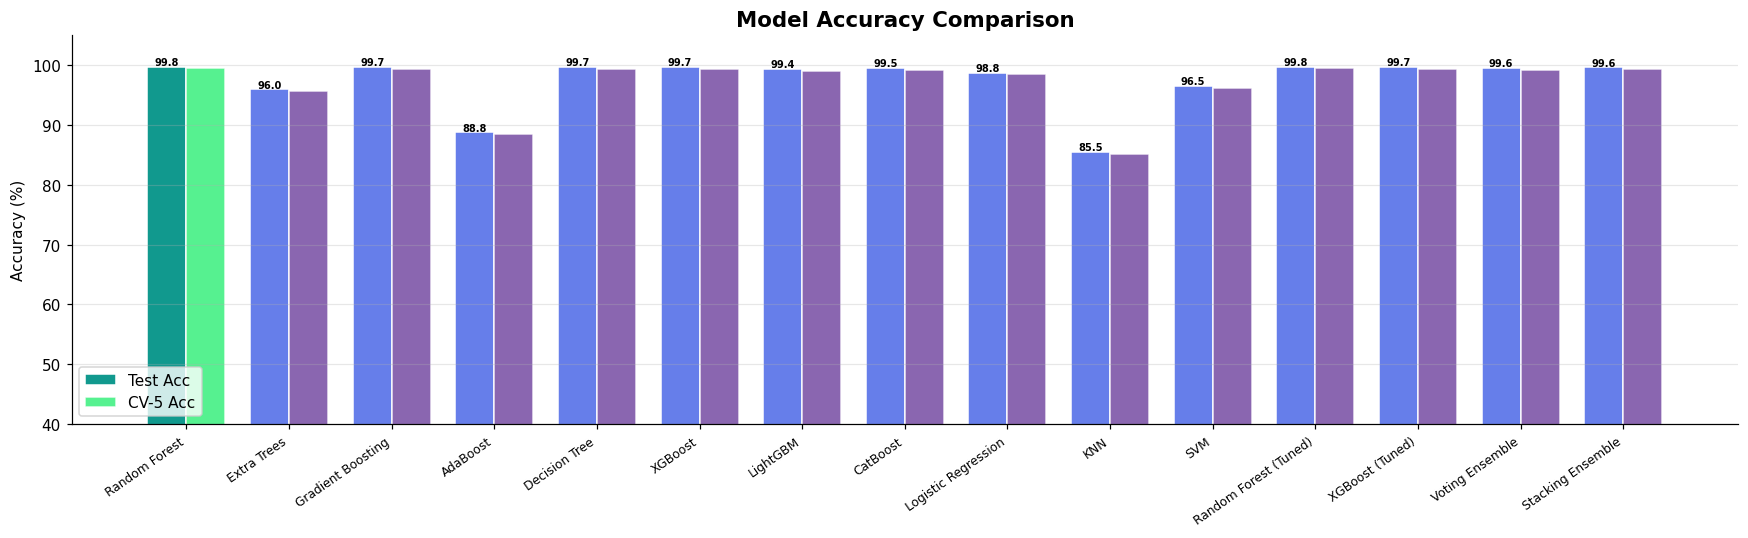

In [13]:
all_names=list(results.keys()); all_test=[results[k]['accuracy']*100 for k in all_names]
all_cv=[results[k]['cv_accuracy']*100 for k in all_names]
fig,ax=plt.subplots(figsize=(16,5)); x=np.arange(len(all_names)); w=0.38
bc=[('#11998e' if n==best_name else '#667eea') for n in all_names]
bcc=[('#38ef7d' if n==best_name else '#764ba2') for n in all_names]
b1=ax.bar(x-w/2,all_test,w,label='Test Acc',color=bc,edgecolor='white')
ax.bar(x+w/2,all_cv,w,label='CV-5 Acc',color=bcc,edgecolor='white',alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(all_names,rotation=35,ha='right',fontsize=8)
ax.set_ylim(40,105); ax.set_ylabel('Accuracy (%)'); ax.legend()
ax.set_title('Model Accuracy Comparison',fontsize=14,fontweight='bold'); ax.grid(axis='y',alpha=0.3)
for b,v in zip(b1,all_test): ax.text(b.get_x()+b.get_width()/2,v+0.3,f'{v:.1f}',ha='center',fontsize=6.5,fontweight='bold')
plt.tight_layout(); plt.savefig('../screenshots/accuracy_comparison.png',dpi=130,bbox_inches='tight'); plt.show()

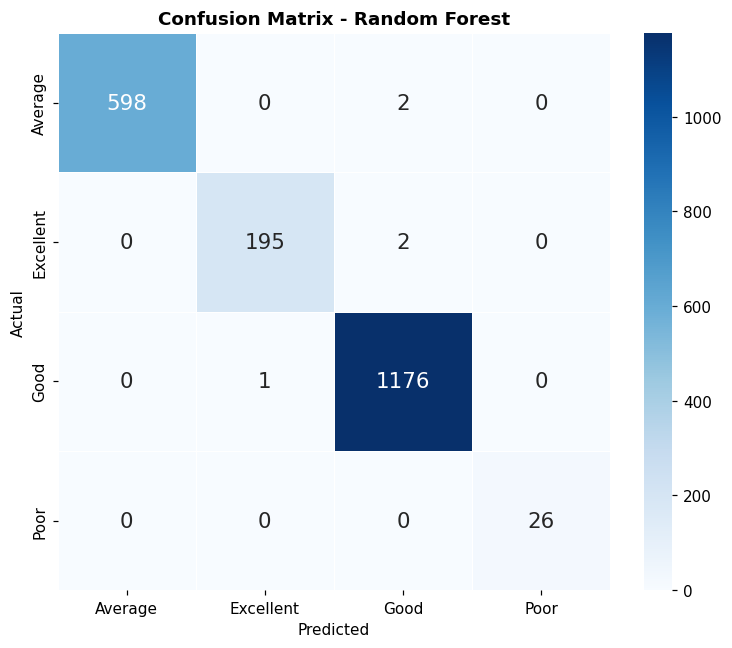

In [14]:
cm=confusion_matrix(y_test,y_pred)
fig,ax=plt.subplots(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=le_target.classes_,yticklabels=le_target.classes_,linewidths=0.6,annot_kws={'size':14},ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(f'Confusion Matrix - {best_name}',fontweight='bold')
plt.tight_layout(); plt.savefig('../screenshots/confusion_matrix.png',dpi=130,bbox_inches='tight'); plt.show()

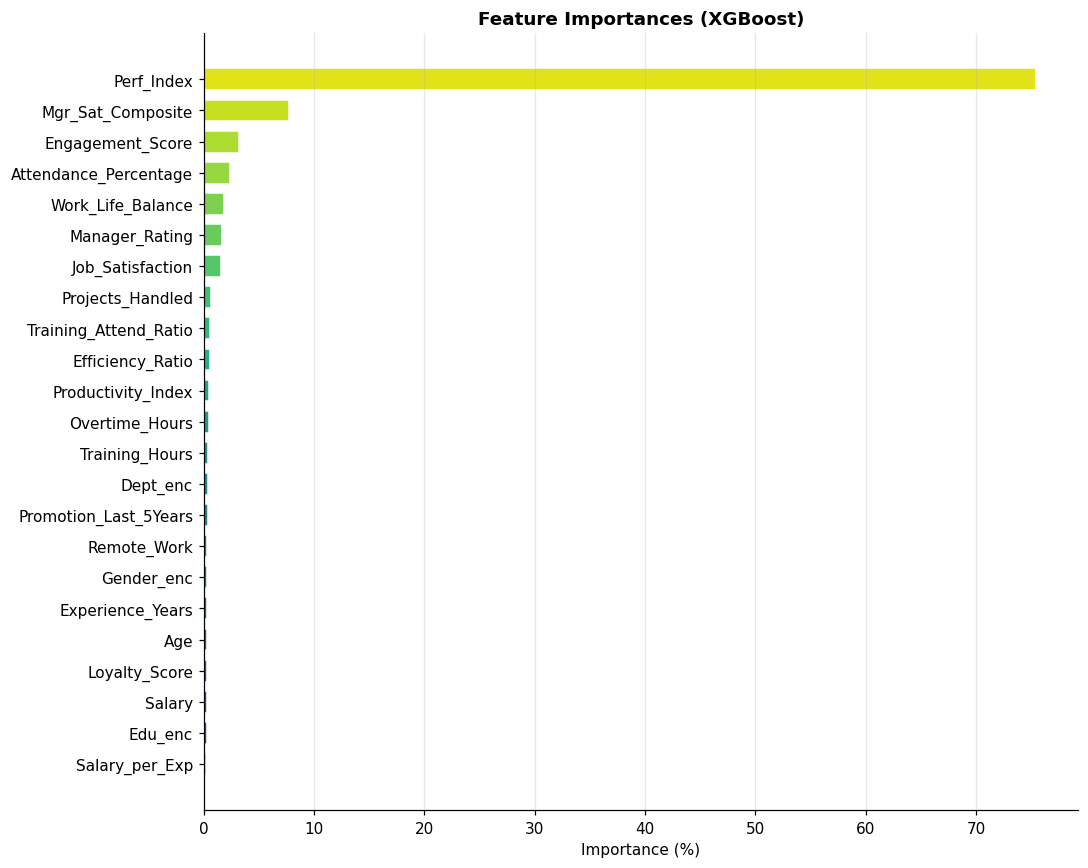

In [15]:
fi=fi_model.feature_importances_; idx=np.argsort(fi)
fig,ax=plt.subplots(figsize=(10,8))
colors=plt.cm.viridis(np.linspace(0.15,0.95,len(FEATURES)))
ax.barh([FEATURES[i] for i in idx],fi[idx]*100,color=colors,edgecolor='white',height=0.7)
ax.set_xlabel('Importance (%)'); ax.set_title('Feature Importances (XGBoost)',fontweight='bold')
ax.grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.savefig('../screenshots/feature_importance.png',dpi=130,bbox_inches='tight'); plt.show()

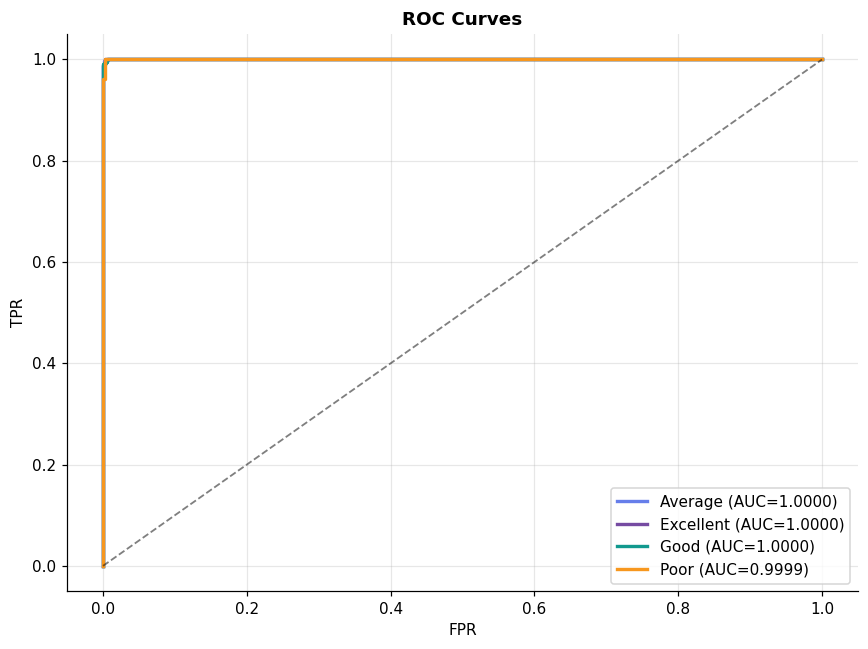

In [16]:
y_test_bin=label_binarize(y_test,classes=list(range(len(le_target.classes_))))
y_score=fi_model.predict_proba(X_test)
fig,ax=plt.subplots(figsize=(8,6))
for i,cls in enumerate(le_target.classes_):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_score[:,i]); ra=auc(fpr,tpr)
    ax.plot(fpr,tpr,lw=2.2,color=PALETTE[i],label=f'{cls} (AUC={ra:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.5); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves',fontweight='bold'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../screenshots/roc_curve.png',dpi=130,bbox_inches='tight'); plt.show()

## 10. 🧠 SHAP Explainability

<Figure size 990x770 with 0 Axes>

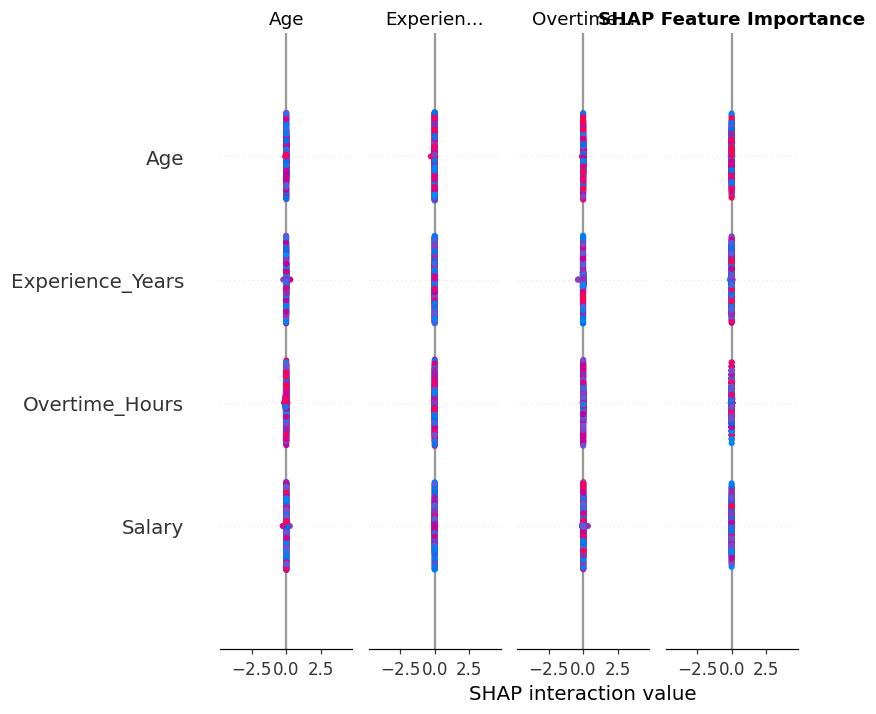

In [17]:
try:
    import shap
    explainer=shap.TreeExplainer(fi_model)
    shap_vals=explainer.shap_values(X_test[:500])
    sv=shap_vals[0] if isinstance(shap_vals,list) else shap_vals
    plt.figure(figsize=(9,7))
    shap.summary_plot(sv,X_test[:500],feature_names=FEATURES,show=False)
    plt.title('SHAP Feature Importance',fontweight='bold'); plt.tight_layout()
    plt.savefig('../screenshots/shap_summary.png',dpi=110,bbox_inches='tight'); plt.show()
except Exception as e:
    print(f'SHAP: {e}')

## 11. 💾 Save All Artifacts

In [18]:
joblib.dump(best_model,'../models/performance_model.pkl')
joblib.dump(scaler,'../models/scaler.pkl')
joblib.dump(le_target,'../models/label_encoder.pkl')
joblib.dump(le_gender,'../models/le_gender.pkl')
joblib.dump(le_dept,'../models/le_dept.pkl')
joblib.dump(le_edu,'../models/le_edu.pkl')
joblib.dump(fi_model,'../models/fi_model.pkl')
meta={'features':FEATURES,'best_model_name':best_name,'use_scaled':False,
      'classes':list(le_target.classes_),'n_samples':N,'n_features':len(FEATURES),
      'results':{k:{'accuracy':v['accuracy'],'cv_accuracy':v['cv_accuracy']} for k,v in results.items()}}
joblib.dump(meta,'../models/meta.pkl')
print('All artifacts saved:')
for f in ['performance_model.pkl','scaler.pkl','label_encoder.pkl','le_gender.pkl','le_dept.pkl','le_edu.pkl','fi_model.pkl','meta.pkl']:
    kb=os.path.getsize(f'../models/{f}')/1024; print(f'  models/{f} ({kb:.0f} KB)')

All artifacts saved:
  models/performance_model.pkl (14729 KB)
  models/scaler.pkl (1 KB)
  models/label_encoder.pkl (0 KB)
  models/le_gender.pkl (0 KB)
  models/le_dept.pkl (1 KB)
  models/le_edu.pkl (1 KB)
  models/fi_model.pkl (1755 KB)
  models/meta.pkl (1 KB)


## 12. 🏆 Final Summary

In [19]:
print('='*60); print('  TRAINING COMPLETE'); print('='*60)
print(f'  Best Model : {best_name}'); print(f'  Accuracy   : {best_acc*100:.4f}%')
print(f'  Dataset    : {N:,} rows x {len(FEATURES)} features')
sorted_res=sorted(results.items(),key=lambda x:x[1]['accuracy'],reverse=True)
print(f"\n  {'Model':<30} {'Test':>8}  {'CV-5':>8}"); print('  '+'-'*50)
for k,v in sorted_res:
    flag=' <<' if k==best_name else ''
    print(f"  {k:<30} {v['accuracy']*100:>7.3f}%  {v['cv_accuracy']*100:>7.3f}%{flag}")
print('\n  Next: cd .. && streamlit run app.py')
print('='*60)

  TRAINING COMPLETE
  Best Model : Random Forest
  Accuracy   : 99.7500%
  Dataset    : 10,000 rows x 23 features

  Model                              Test      CV-5
  --------------------------------------------------
  Random Forest                   99.750%   99.451% <<
  Random Forest (Tuned)           99.750%   99.451%
  Gradient Boosting               99.700%   99.401%
  Decision Tree                   99.700%   99.401%
  XGBoost                         99.700%   99.401%
  XGBoost (Tuned)                 99.650%   99.351%
  Stacking Ensemble               99.600%   99.301%
  Voting Ensemble                 99.550%   99.251%
  CatBoost                        99.500%   99.201%
  LightGBM                        99.350%   99.052%
  Logistic Regression             98.750%   98.454%
  SVM                             96.500%   96.210%
  Extra Trees                     95.950%   95.662%
  AdaBoost                        88.750%   88.484%
  KNN                             85.450%   85.19